## 1. Setup and dependencies

In [1]:
!pip install -q open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00


In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import open_clip

import time
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


In [4]:
DATASET_PATH = Path("/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset")

IMAGE_DIR = DATASET_PATH / "images"
IMAGES_CSV = DATASET_PATH / "images.csv"

print("Images directory:", IMAGE_DIR.exists())
print("Images CSV:", IMAGES_CSV.exists())

Images directory: True
Images CSV: True


## 2. Dataset and metadata

In [5]:
PRODUCTS_PATH = Path(
    "/kaggle/input/notebooks/jndhruv/02-data-cleaning/multi-modal-fashion-ecom/"
    "data/processed/products.parquet"
)

products_df = pd.read_parquet(PRODUCTS_PATH)

print("Shape:", products_df.shape)
print("Columns:", products_df.columns.tolist())

Shape: (44419, 23)
Columns: ['id', 'product_display_name', 'brand_name', 'gender', 'master_category', 'sub_category', 'article_type', 'base_colour', 'season', 'usage', 'year', 'price', 'discounted_price', 'description', 'image_url', 'pattern', 'fabric', 'sleeve_length', 'occasion', 'fit', 'neck', 'length', 'search_text']


In [6]:
print("\nMissing values:")
display(products_df.isna().sum().sort_values(ascending=False).head(10))


Missing values:


length           40982
neck             35082
fit              34338
occasion         33424
sleeve_length    31590
fabric           28835
pattern          27926
description         68
season              21
usage                1
dtype: int64

In [7]:
print("\nSample products:")
display(
    products_df[
        ["id", "product_display_name", "brand_name",
         "master_category", "sub_category", "search_text"]
    ].head()
)


Sample products:


,id,product_display_name,brand_name,master_category,sub_category,search_text
0,1566,Artengo Men Black Cap,Artengo,Accessories,Headwear,Artengo Men Black Cap Artengo Accessories Head...
1,39342,Fila Men Zoom Black Shoes,FILA,Footwear,Shoes,Fila Men Zoom Black Shoes FILA Footwear Shoes ...
2,13182,FILA Men Dls Maxim Black Sports Shoes,FILA,Footwear,Shoes,FILA Men Dls Maxim Black Sports Shoes FILA Foo...
3,21762,Fossil Men Mead Black Belt,Fossil,Accessories,Belts,Fossil Men Mead Black Belt Fossil Accessories ...
4,48692,Lucera Women Silver Earrings,Lucera,Accessories,Jewellery,Lucera Women Silver Earrings Lucera Accessorie...


## 3. Validate Image <--> Product mapping

In [8]:
image_paths = products_df["id"].astype(str).map(
    lambda product_id: IMAGE_DIR / f"{product_id}.jpg"
)

images_exist = image_paths.map(Path.exists)

print("Products:", len(products_df))
print("Images found:", images_exist.sum())
print("Images missing:", (~images_exist).sum())
print("Mapping complete:", images_exist.all())

Products: 44419
Images found: 44419
Images missing: 0
Mapping complete: True


In [9]:
# Identify products whose local images are missing

missing_products = products_df.loc[
    ~images_exist,
    ["id", "product_display_name", "image_url"]
].copy()

print(f"Missing images: {len(missing_products)}")

display(missing_products)

Missing images: 0


,id,product_display_name,image_url


In [10]:
images_df = pd.read_csv(IMAGES_CSV)

missing_ids = set(missing_products["id"].astype(str))

csv_matches = images_df[
    images_df["filename"].str.replace(".jpg", "", regex=False).isin(missing_ids)
]

display(csv_matches)

,filename,link


We identify that there are 5 records who are missing a local image but have links to their images. So for now we exclude them from our embeddings experiment

In [11]:
products_df["image_path"] = products_df["id"].astype(str).map(
    lambda product_id: IMAGE_DIR / f"{product_id}.jpg"
)

products_df["image_exists"] = products_df["image_path"].map(Path.exists)

embedding_df = products_df[products_df["image_exists"]].copy()

print("Total products:", len(products_df))
print("Usable products:", len(embedding_df))
print("Products without local images:", (~products_df["image_exists"]).sum())

Total products: 44419
Usable products: 44419
Products without local images: 0


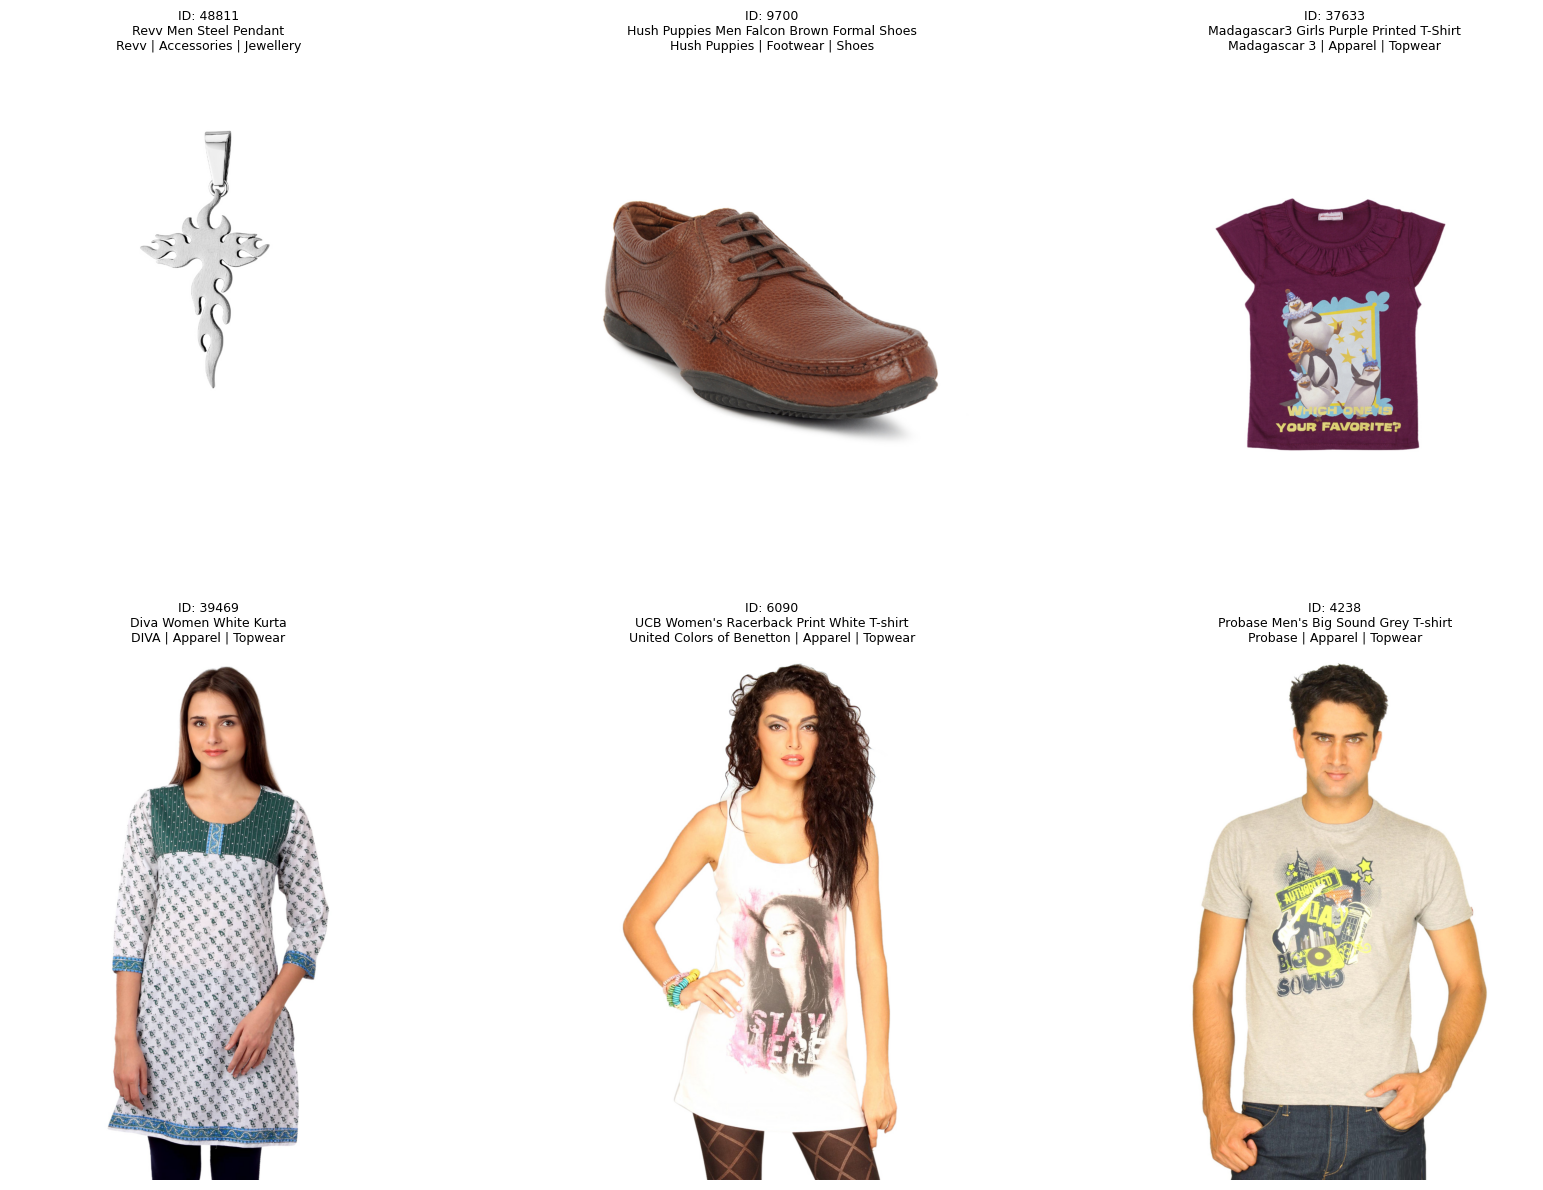

In [12]:
sample_df = embedding_df.sample(
    n=6,
    random_state=SEED
).reset_index(drop=True)

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 12)
)

for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):

    image = Image.open(row["image_path"]).convert("RGB")

    ax.imshow(image)
    ax.axis("off")

    title = (
        f"ID: {row['id']}\n"
        f"{row['product_display_name']}\n"
        f"{row['brand_name']} | "
        f"{row['master_category']} | "
        f"{row['sub_category']}"
    )

    ax.set_title(title, fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
for _, row in sample_df.iterrows():

    print("=" * 100)
    print(f"ID: {row['id']}")
    print(f"Product: {row['product_display_name']}")
    print(f"Brand: {row['brand_name']}")
    print(f"Category: {row['master_category']} / {row['sub_category']}")
    print("\nSearch text:")
    print(row["search_text"])

ID: 48811
Product: Revv Men Steel Pendant
Brand: Revv
Category: Accessories / Jewellery

Search text:
Revv Men Steel Pendant Revv Accessories Jewellery Pendant Steel Casual Western revv is an imported stainless steel collection that suits the trendsetting youth of today - cool college goers, young executives and those who like to remain ahead of the pack.
ID: 9700
Product: Hush Puppies Men Falcon Brown Formal Shoes
Brand: Hush Puppies
Category: Footwear / Shoes

Search text:
Hush Puppies Men Falcon Brown Formal Shoes Hush Puppies Footwear Shoes Formal Shoes Brown Formal If you want the ultimate sensation of comfort for your feet, then these shoes from hush puppies are made for you. These lace-up oxfords with the sporty outsole features herringbone pattern that gives superior grip.Team these with jeans or chinos and tees for a cool look. Upper Leather uppers for durability and comfort Stitch detailing for added style Lace-ups for a snug Fit Lightly padded collar for greater comfort Mids

## 4. Embedding Model

In [14]:
MODEL_NAME = "hf-hub:Marqo/marqo-fashionCLIP"

model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(
    MODEL_NAME
)

tokenizer = open_clip.get_tokenizer(MODEL_NAME)

model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")

open_clip_config.json:   0%|          | 0.00/532 [00:00<?, ?B/s]

open_clip_model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Model loaded successfully.


In [15]:
print("Model:", MODEL_NAME)
print("Device:", DEVICE)
print("Embedding dimension:", model.visual.output_dim)

Model: hf-hub:Marqo/marqo-fashionCLIP
Device: cuda
Embedding dimension: 512


In [16]:
# Single image + text embedding smoke test

sample = embedding_df.iloc[0]

image = Image.open(sample["image_path"]).convert("RGB")

image_input = preprocess_val(image).unsqueeze(0).to(DEVICE)
text_input = tokenizer([sample["search_text"]]).to(DEVICE)

with torch.no_grad():
    image_embedding = model.encode_image(image_input)
    text_embedding = model.encode_text(text_input)

print("Image shape:", image_embedding.shape)
print("Text shape:", text_embedding.shape)

Image shape: torch.Size([1, 512])
Text shape: torch.Size([1, 512])


In [17]:
image_embedding = image_embedding / image_embedding.norm(dim=-1, keepdim=True)
text_embedding = text_embedding / text_embedding.norm(dim=-1, keepdim=True)

print("Image norm:", image_embedding.norm(dim=-1).item())
print("Text norm:", text_embedding.norm(dim=-1).item())

similarity = (image_embedding @ text_embedding.T).item()

print("Image <--> text cosine similarity:", similarity)

Image norm: 1.0
Text norm: 1.0
Image <--> text cosine similarity: 0.26180344820022583


## 5. Image Embedding Generation

### Benchmarking for a batch size of 32

In [18]:
BATCH_SIZE = 32

benchmark_df = embedding_df.iloc[:BATCH_SIZE]

benchmark_images = []

for image_path in benchmark_df["image_path"]:
    image = Image.open(image_path).convert("RGB")
    benchmark_images.append(preprocess_val(image))

image_batch = torch.stack(benchmark_images).to(DEVICE)

print("Image batch shape:", image_batch.shape)
print("Device:", image_batch.device)

Image batch shape: torch.Size([32, 3, 224, 224])
Device: cuda:0


In [19]:
# Reset CUDA memory statistics
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats(DEVICE)

# Make sure CUDA operations are synchronized before timing
torch.cuda.synchronize()

start_time = time.perf_counter()

with torch.no_grad():
    benchmark_embeddings = model.encode_image(image_batch)

torch.cuda.synchronize()

elapsed_time = time.perf_counter() - start_time

# L2 normalization
benchmark_embeddings = (
    benchmark_embeddings
    / benchmark_embeddings.norm(dim=-1, keepdim=True)
)

peak_memory_mb = (
    torch.cuda.max_memory_allocated(DEVICE)
    / (1024 ** 2)
)

print("Embedding shape:", benchmark_embeddings.shape)
print("Elapsed time:", f"{elapsed_time:.4f} seconds")
print("Images/second:", f"{BATCH_SIZE / elapsed_time:.2f}")
print("Peak GPU memory:", f"{peak_memory_mb:.2f} MB")
print(
    "Embedding norms:",
    benchmark_embeddings.norm(dim=-1)[:5].cpu().numpy()
)

Embedding shape: torch.Size([32, 512])
Elapsed time: 0.3945 seconds
Images/second: 81.12
Peak GPU memory: 823.24 MB
Embedding norms: [1.         1.         0.99999994 1.         1.        ]


### Benchmarking Image Embeddings Generation

In [20]:
class FashionImageDataset(Dataset):

    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)

        return image, row["id"]

In [21]:
BATCH_SIZE = 32

image_dataset = FashionImageDataset(
    embedding_df,
    preprocess_val
)

image_loader = DataLoader(
    image_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Dataset size:", len(image_dataset))
print("Number of batches:", len(image_loader))

Dataset size: 44419
Number of batches: 1389


In [22]:
benchmark_dataset = FashionImageDataset(
    embedding_df.iloc[:128],
    preprocess_val
)

benchmark_loader = DataLoader(
    benchmark_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [23]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats(DEVICE)

torch.cuda.synchronize()
start_time = time.perf_counter()

benchmark_embeddings = []

with torch.no_grad():

    for image_batch, _ in benchmark_loader:

        image_batch = image_batch.to(
            DEVICE,
            non_blocking=True
        )

        batch_embeddings = model.encode_image(image_batch)

        batch_embeddings = (
            batch_embeddings
            / batch_embeddings.norm(dim=-1, keepdim=True)
        )

        benchmark_embeddings.append(
            batch_embeddings.cpu()
        )

torch.cuda.synchronize()

elapsed_time = time.perf_counter() - start_time

benchmark_embeddings = torch.cat(
    benchmark_embeddings,
    dim=0
)

peak_memory_mb = (
    torch.cuda.max_memory_allocated(DEVICE)
    / (1024 ** 2)
)

print("Embedding shape:", benchmark_embeddings.shape)
print("Elapsed time:", f"{elapsed_time:.2f} seconds")
print(
    "Throughput:",
    f"{128 / elapsed_time:.2f} images/s"
)
print(
    "Peak GPU memory:",
    f"{peak_memory_mb:.2f} MB"
)

Embedding shape: torch.Size([128, 512])
Elapsed time: 4.02 seconds
Throughput: 31.84 images/s
Peak GPU memory: 823.30 MB


### Generate Full Image Embeddings

In [24]:
image_embeddings = []

start_time = time.perf_counter()

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats(DEVICE)

torch.cuda.synchronize()

with torch.no_grad():

    for image_batch, _ in tqdm(
        image_loader,
        desc="Generating image embeddings"
    ):

        image_batch = image_batch.to(
            DEVICE,
            non_blocking=True
        )

        batch_embeddings = model.encode_image(image_batch)

        batch_embeddings = (
            batch_embeddings
            / batch_embeddings.norm(dim=-1, keepdim=True)
        )

        image_embeddings.append(
            batch_embeddings.cpu()
        )

        del image_batch, batch_embeddings

torch.cuda.synchronize()

image_embedding_time = time.perf_counter() - start_time

image_embeddings = torch.cat(
    image_embeddings,
    dim=0
)

peak_memory_mb = (
    torch.cuda.max_memory_allocated(DEVICE)
    / (1024 ** 2)
)

print("\nImage embedding generation complete.")
print("Shape:", image_embeddings.shape)
print("Time:", f"{image_embedding_time:.2f} seconds")
print(
    "Throughput:",
    f"{len(embedding_df) / image_embedding_time:.2f} images/s"
)
print(
    "Peak GPU memory:",
    f"{peak_memory_mb:.2f} MB"
)

Generating image embeddings:   0%|          | 0/1389 [00:00<?, ?it/s]


Image embedding generation complete.
Shape: torch.Size([44419, 512])
Time: 1283.51 seconds
Throughput: 34.61 images/s
Peak GPU memory: 823.30 MB


In [25]:
# Validate full image embeddings

assert image_embeddings.shape == (
    len(embedding_df),
    512
)

norms = image_embeddings.norm(dim=-1)

print("Shape:", image_embeddings.shape)
print("Min norm:", norms.min().item())
print("Max norm:", norms.max().item())
print("Mean norm:", norms.mean().item())

print("\nFirst 5 product IDs:")
print(embedding_df["id"].head().tolist())

print("\nFirst 5 embedding rows:")
print(image_embeddings[:5].shape)

Shape: torch.Size([44419, 512])
Min norm: 0.9999998211860657
Max norm: 1.0000001192092896
Mean norm: 1.0

First 5 product IDs:
[1566, 39342, 13182, 21762, 48692]

First 5 embedding rows:
torch.Size([5, 512])


In [26]:
np.save("/kaggle/working/image_embeddings.npy", image_embeddings.numpy())
np.save("/kaggle/working/image_embedding_ids.npy", embedding_df["id"].values)